# Partition scenarios — how validation design changes conclusions


## Scientific question
How sensitive is model performance to the partitioning regime? We compare two **externally prepared membership plans** on the same samples: a balanced fold plan and a group-blocked plan. In production these plans should be generated upstream (for example with BioSieve). `saber` only consumes the memberships.


In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEMO_TEST = os.getenv("SABER_DEMO_TEST") == "1"

def balanced_fold_labels(y, n_splits):
    """Demo-only external memberships. Production partition generation belongs to BioSieve."""
    y = np.asarray(y)
    folds = np.empty(len(y), dtype=int)
    for label in np.unique(y):
        idx = np.flatnonzero(y == label)
        folds[idx] = np.arange(len(idx)) % n_splits
    return folds

from sklearn.datasets import make_classification
from saber import benchmark
from saber.benchmark import BenchmarkConfig
from saber.datasets import DatasetBundle, PartitionPlan


In [2]:
rng=np.random.default_rng(90)
n_groups=20 if DEMO_TEST else 40; per_group=8
n=n_groups*per_group
groups=np.repeat(np.arange(n_groups),per_group)
# Global predictive signal + group-specific nuisance dimensions.
X,y=make_classification(n_samples=n,n_features=10,n_informative=6,n_redundant=1,class_sep=.9,random_state=90)
group_signal=rng.normal(size=(n_groups,3))[groups]
X=np.column_stack([X,group_signal])
ids=np.asarray([f"part_{i:04d}" for i in range(n)],dtype=object)
dataset=DatasetBundle(X=X,y=y,sample_ids=ids,groups=groups,feature_names=[f"f{i}" for i in range(X.shape[1])])
# Scenario A: balanced memberships across labels.
balanced=PartitionPlan.from_predefined_folds(sample_ids=ids,fold_assignments=balanced_fold_labels(y,4),dataset_fingerprint=dataset.fingerprint,
                                              metadata={"source":"external","strategy":"balanced_random_like"})
# Scenario B: whole groups are held out together; no group spans train/evaluation.
group_folds=groups%4
group_blocked=PartitionPlan.from_predefined_folds(sample_ids=ids,fold_assignments=group_folds,dataset_fingerprint=dataset.fingerprint,
                                                   metadata={"source":"external","strategy":"group_blocked_like"})


In [3]:
bench=benchmark(datasets={"prepared":dataset},algorithms=("logistic_regression","random_forest"),
                partitions={"balanced":balanced,"group_blocked":group_blocked},
                config=BenchmarkConfig(metrics=("mcc","balanced_accuracy","f1","roc_auc"),seeds=(42,),modes=("untuned",),include_baselines=True),
                model_params={"random_forest":{"n_estimators":50 if DEMO_TEST else 120,"max_depth":7}})
assert not bench.failures
metrics=bench.aggregate_metrics_frame().to_pandas(); folds=bench.fold_metrics_frame().to_pandas()
comparison=(metrics[metrics.metric=="mcc"].pivot_table(index="algorithm",columns="partition",values="score"))
comparison["delta_group_minus_balanced"]=comparison["group_blocked"]-comparison["balanced"]
comparison


partition,balanced,group_blocked,delta_group_minus_balanced
algorithm,,,
dummy_classifier,0.000000,0.000000,0.00000
logistic_regression,0.645869,0.632459,-0.01341
random_forest,0.694151,0.726521,0.03237


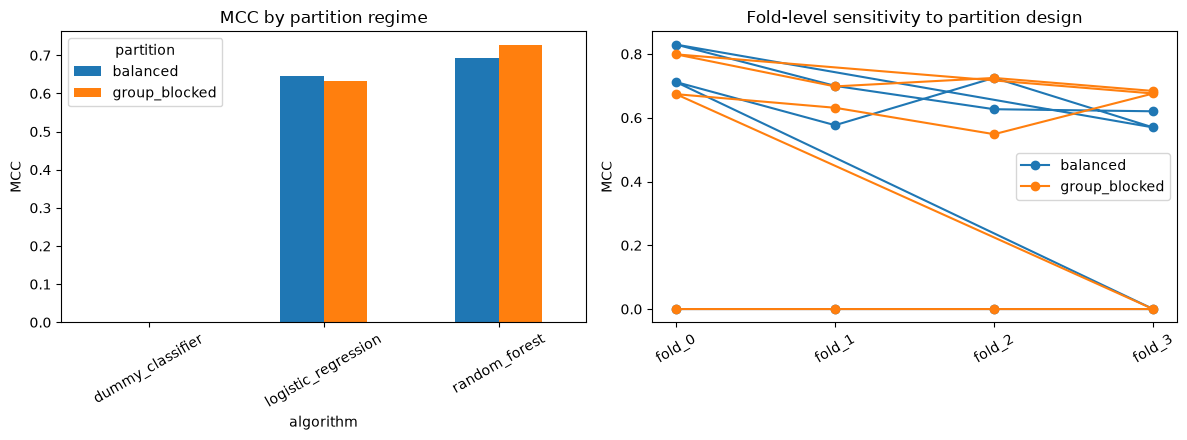

In [4]:
# Confirm group isolation for the blocked plan.
leak_checks=[]
for split in group_blocked.splits:
    train_groups=set(dataset.subset(split.train_ids).groups)
    eval_groups=set(dataset.subset(split.validation_ids).groups)
    leak_checks.append(len(train_groups & eval_groups)==0)
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
comparison[["balanced","group_blocked"]].plot.bar(ax=axes[0]); axes[0].set(title="MCC by partition regime",ylabel="MCC"); axes[0].tick_params(axis="x",rotation=30)
fold_mcc=folds[folds.metric=="mcc"]
for name,part in fold_mcc.groupby("partition"): axes[1].plot(part.split,part.score,marker="o",label=name)
axes[1].set(title="Fold-level sensitivity to partition design",ylabel="MCC"); axes[1].tick_params(axis="x",rotation=30); axes[1].legend()
plt.tight_layout(); FIGURE_COUNT=1


In [5]:
DEMO_CHECKS={
    "two_partition_scenarios":set(metrics.partition)=={"balanced","group_blocked"},
    "group_isolation":all(leak_checks),
    "no_failures":len(bench.failures)==0,
    "comparison_report":set(comparison.columns)>={"balanced","group_blocked","delta_group_minus_balanced"},
    "fold_results":folds.split.nunique()==4,
    "figure_created":FIGURE_COUNT==1,
}
assert all(DEMO_CHECKS.values()), DEMO_CHECKS
DEMO_CHECKS


{'two_partition_scenarios': True,
 'group_isolation': True,
 'no_failures': True,
 'comparison_report': True,
 'fold_results': True,
 'figure_created': True}